In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [26]:
pop_files = ["qcflag-5_part0", "kickflag-1_part0", "bhflag-3_part0", "bhflag-3_kickflag-1_part0"]
pops = [cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/{f}", parts=[]) for f in pop_files]

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(


In [64]:
labels = ["Disberg", "Hobbs", "Disberg (No Fallback)", "Hobbs (No Fallback)"]
for pop, f in zip(pops, labels):
    pop.label = f

colours = ["tab:blue", "tab:orange", "tab:blue", "tab:orange"]

linestyles = ["-", "-", ":", ":"]

for i, pop in enumerate(pops):
    pop.colour = colours[i]
    pop.linestyle = linestyles[i]
    pop.bpp["row_num"] = np.arange(len(pop.bpp))

In [28]:
reload(helpers)
reload(plotting)

<module 'plotting' from '/mnt/home/twagg/projects/underworld/analysis/../src/plotting.py'>

In [29]:
kinematics = helpers.get_kinematics(pops)

In [30]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Disberg:
      - CO = 0.106
      - BH = 0.029
      - NS = 0.136
  - Hobbs:
      - CO = 0.162
      - BH = 0.032
      - NS = 0.212
  - Disberg (No Fallback):
      - CO = 0.142
      - BH = 0.158
      - NS = 0.136
  - Hobbs (No Fallback):
      - CO = 0.224
      - BH = 0.255
      - NS = 0.212


200067
200794
200367
201200


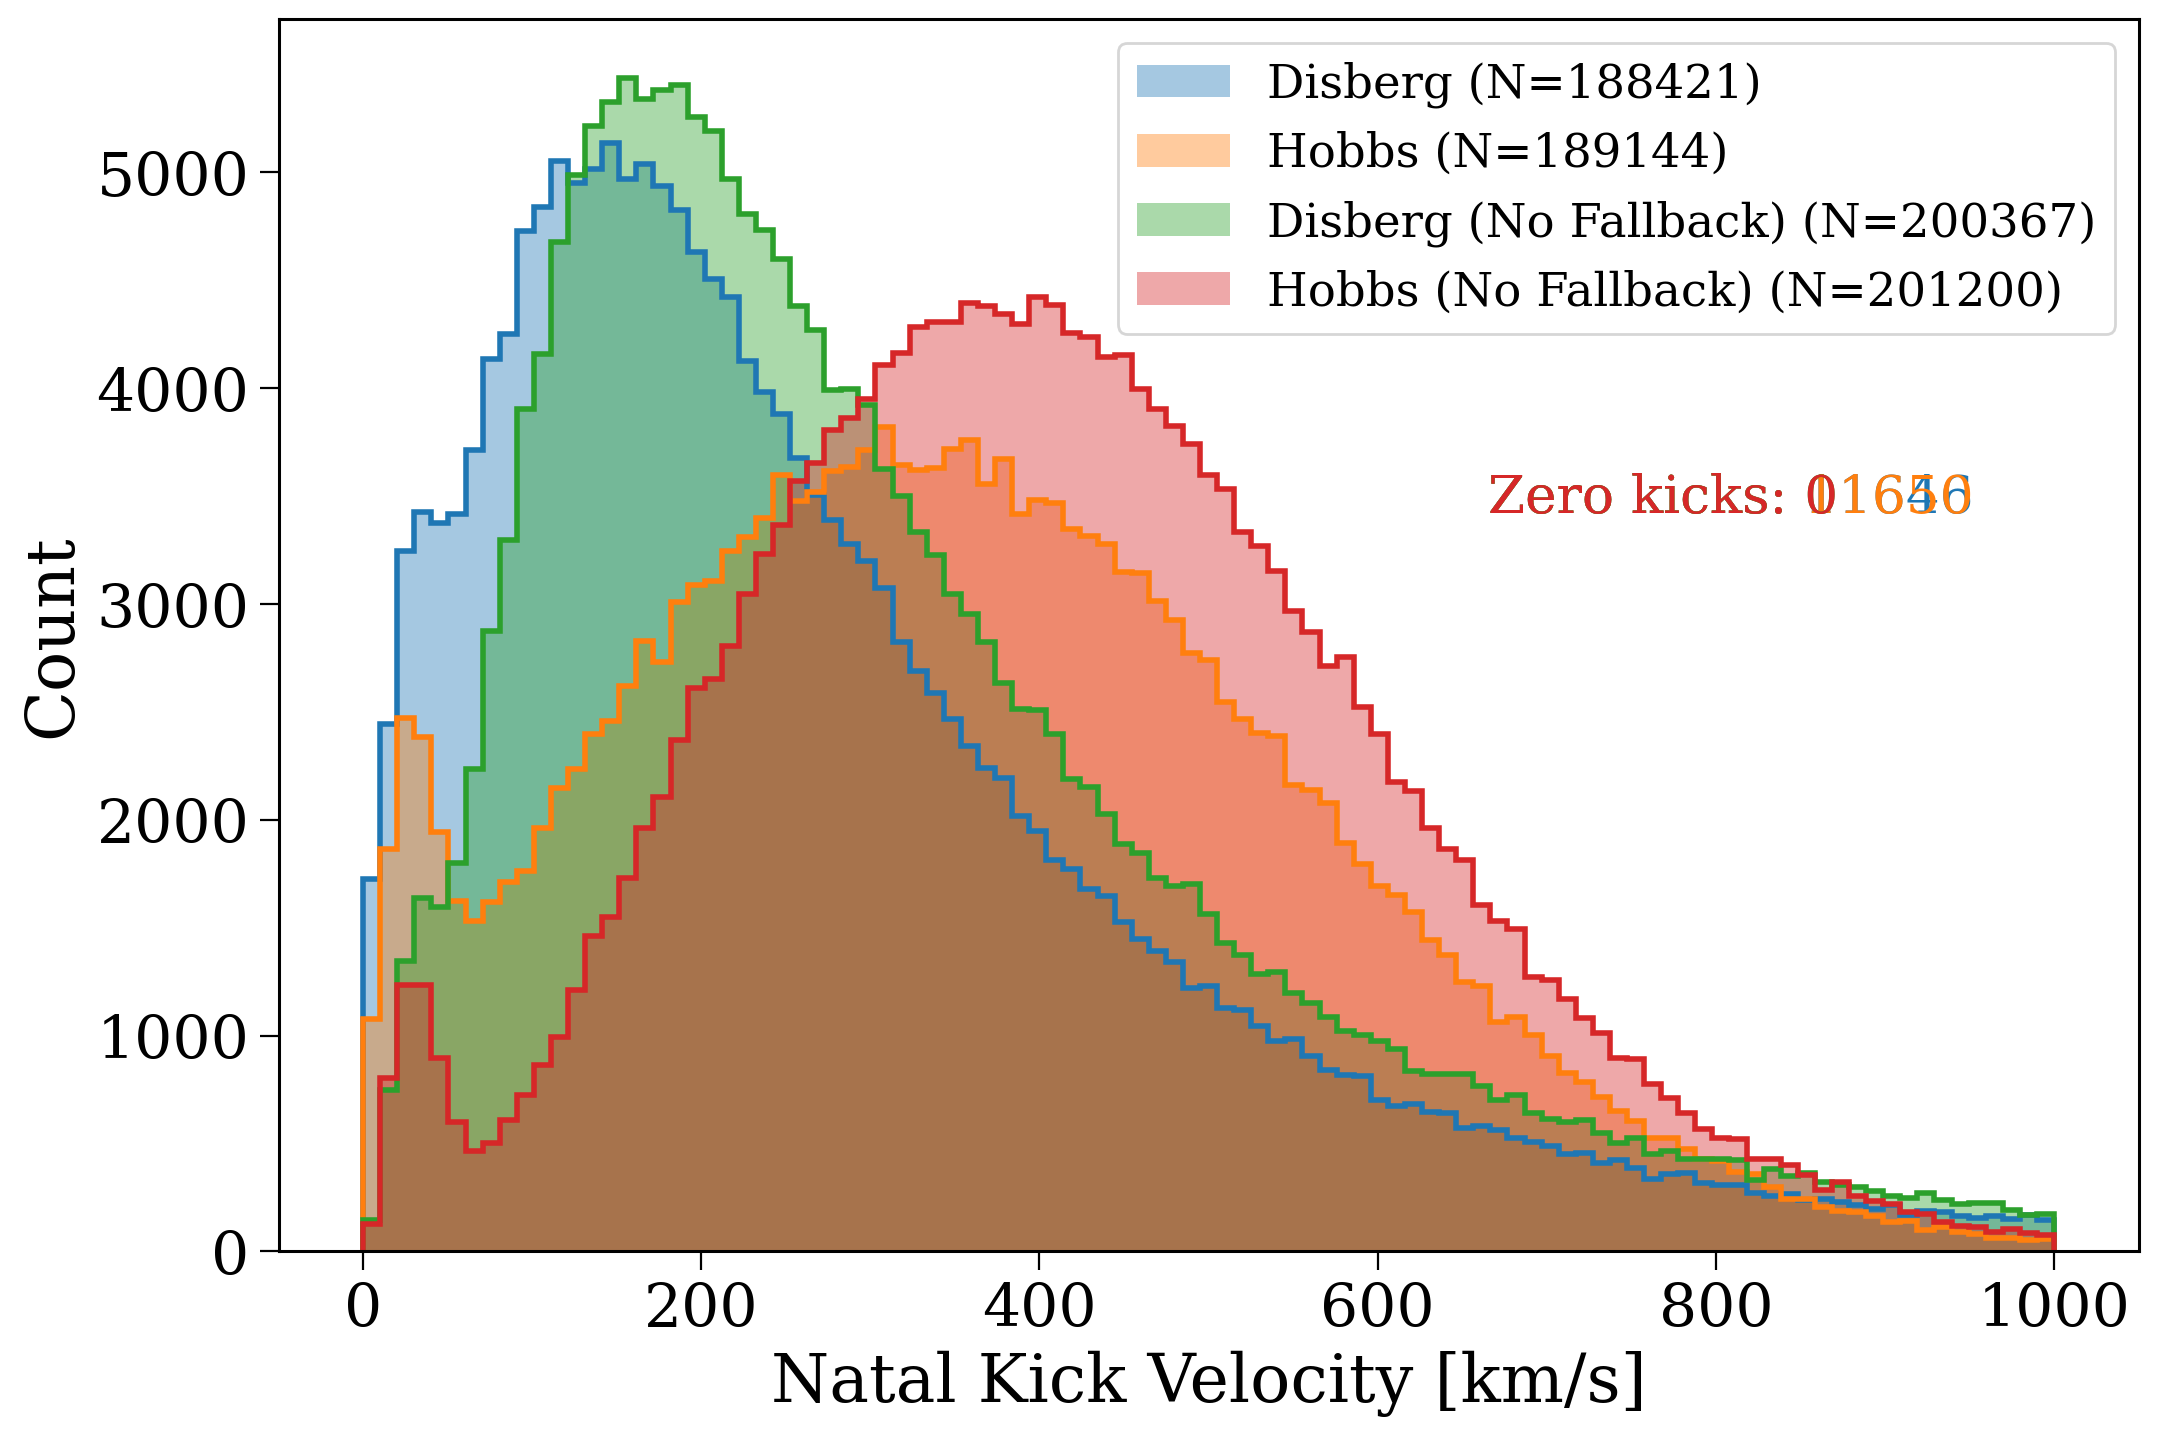

200067
200794
200367
201200


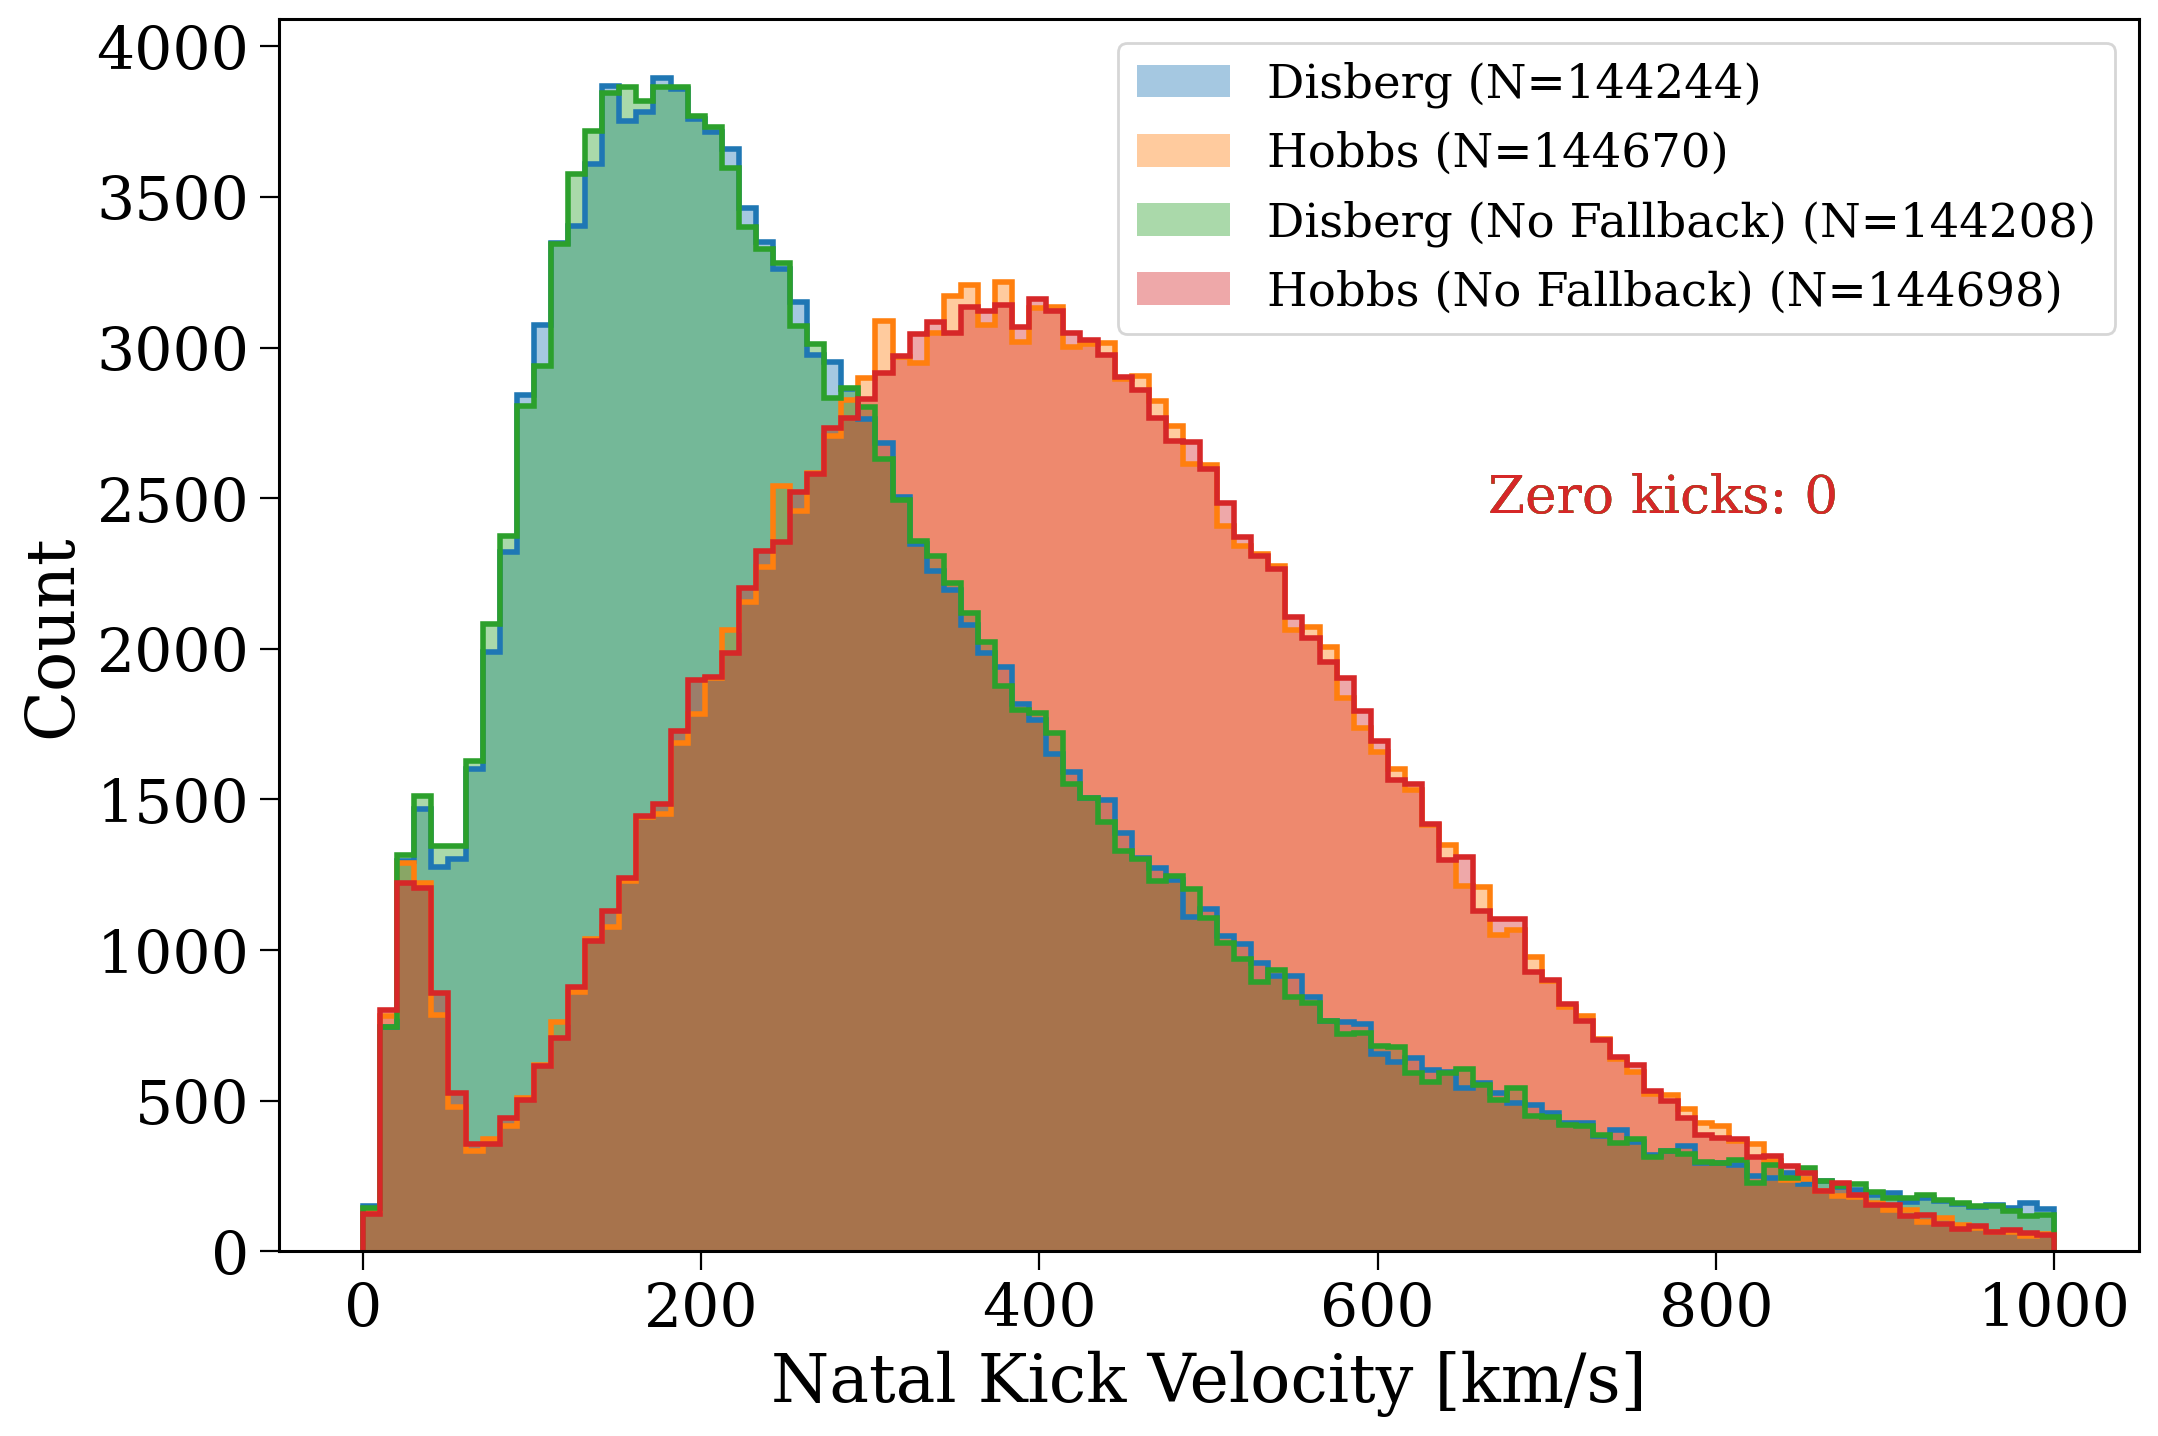

200067
200794
200367
201200


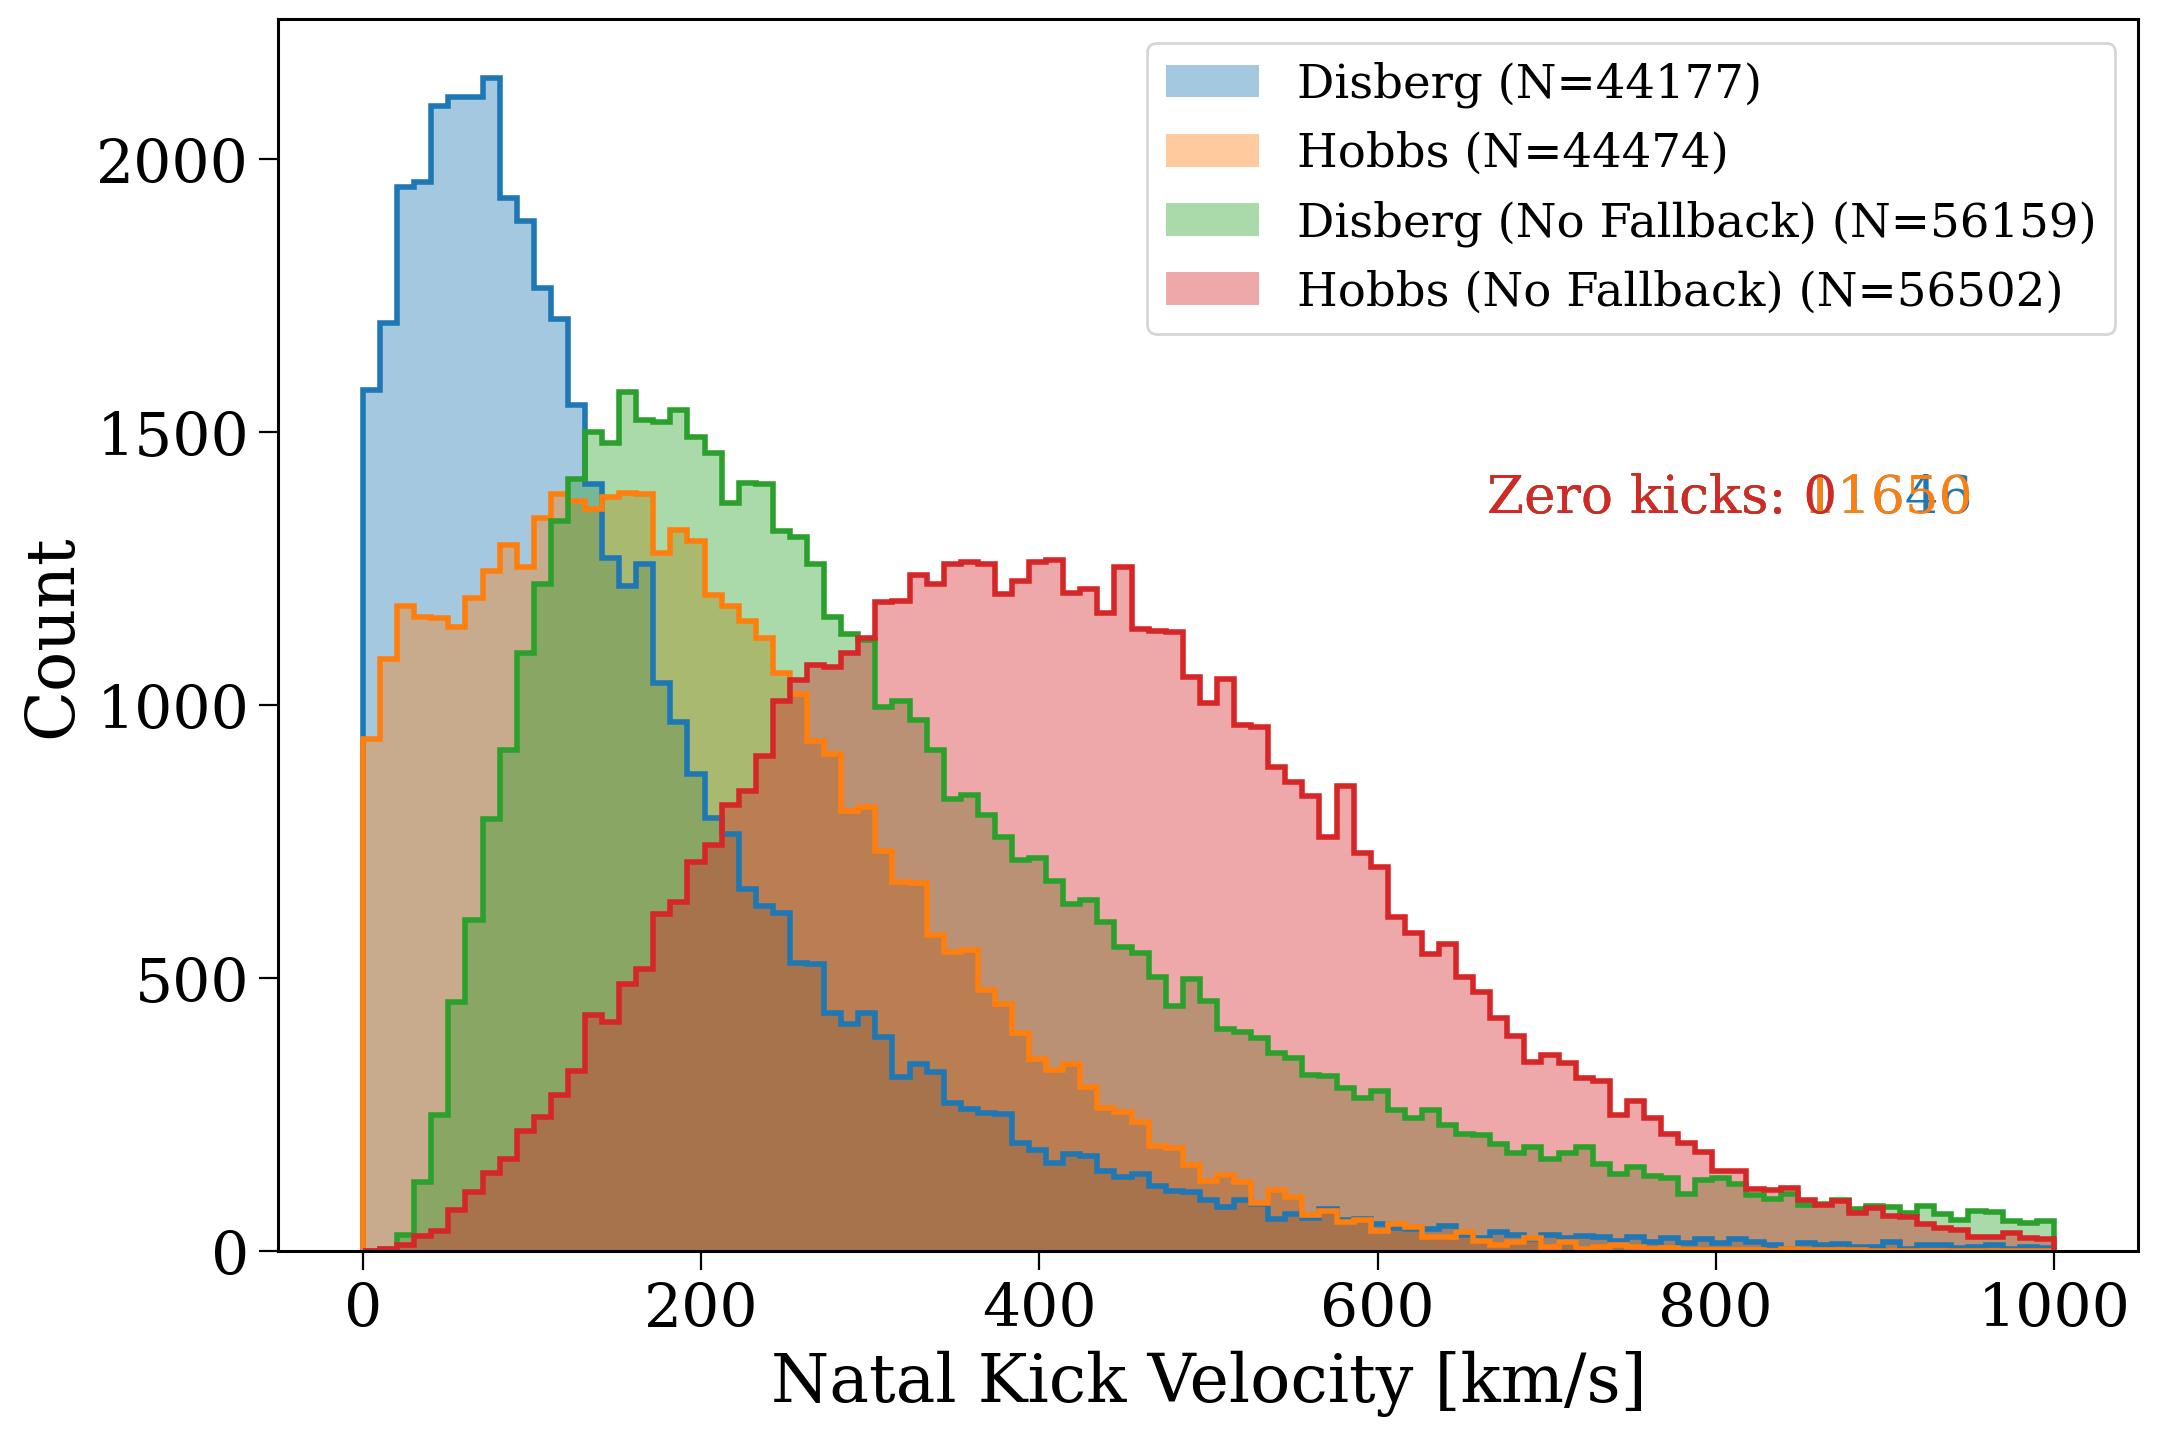

In [31]:
density = False
for co_type_label, co_type in zip(["ALL", "NS", "BH"], [[13, 14], [13], [14]]):

    fig, ax = plt.subplots()

    bins = np.linspace(0, 1000, 100)

    for pop in pops:
        kick_details = pop.kick_info[pop.kick_info["star"] != 0]
        kicks = kick_details["natal_kick"]
        print(len(kicks))

        kick_rows = pop.bpp[pop.bpp["evol_type"].isin([15, 16])]
        after_kick_rows = pop.bpp[pop.bpp["row_num"].isin(kick_rows["row_num"] + 1)]
        kick_co_type = np.where(kick_details["star"] == 1, after_kick_rows["kstar_1"], after_kick_rows["kstar_2"])
        
        kicks = kicks[(np.isin(kick_co_type, co_type))]
        n_zero_kicks = (kicks == 0.0).sum()
        kicks = kicks[(kicks != 0.0)]

        ax.hist(kicks, bins=bins, density=density, histtype='step', lw=2, color=pop.colour)
        ax.hist(kicks, bins=bins, density=density, alpha=0.4, color=pop.colour,
                label=f"{pop.label} (N={len(kicks)})")
        
        ax.annotate(
            f"Zero kicks: {n_zero_kicks}",
            xy=(0.65, 0.65 - 0.05 * (0 if pop.label == "Singles" else 1)),
            xycoords='axes fraction',
            color=pop.colour,
            fontsize=0.8*fs,
        )

    ax.set(
        xlabel="Natal Kick Velocity [km/s]",
        ylabel="Count",
    )
    ax.legend()
    plt.show()

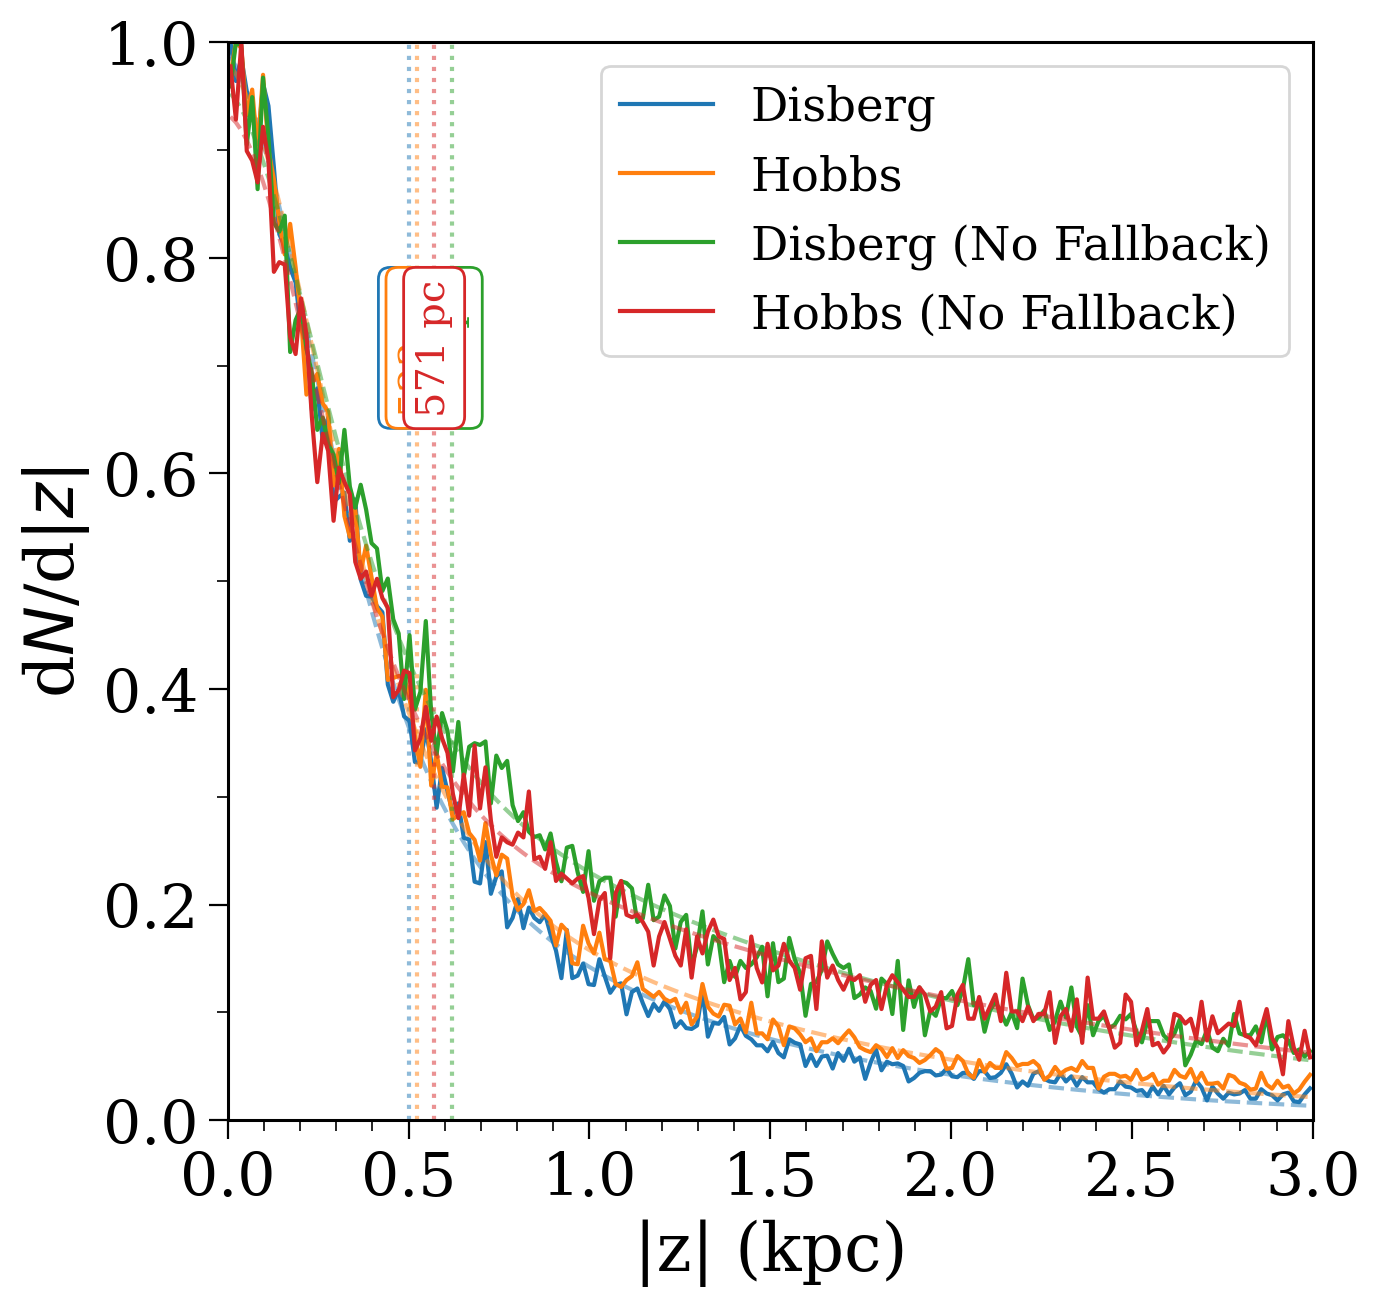

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for pop in pops:

    scale_height, _, _ = plotting.estimate_scale_height(
        z=kinematics[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[0.78, 0.22],
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [33]:
mass = {}
for pop in pops:

    masses = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))

    mass[pop.label] = masses

In [36]:
print("Average BH masses:")
print("------------------")

for pop in pops:
    masses = mass[pop.label]

    average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
    average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

    avg_bound_BH_close_to_disc = np.mean(masses["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
    )])

    avg_bound_BH_far_from_disc = np.mean(masses["BH"][(
        ~kinematics[pop.label]["escaped"]["BH"] &
        (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
    )])

    print(f"{pop.label}")
    print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
    print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
    print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
    print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")
    print()

Average BH masses:
------------------
Disberg
  Escaped: 5.3 Msun
  Bound:   10.8 Msun
    Close to disc (<1 kpc):  11.9 Msun
    Far from disc (>=1 kpc): 8.0 Msun

Hobbs
  Escaped: 4.8 Msun
  Bound:   10.8 Msun
    Close to disc (<1 kpc):  12.6 Msun
    Far from disc (>=1 kpc): 7.7 Msun

Disberg (No Fallback)
  Escaped: 11.2 Msun
  Bound:   10.5 Msun
    Close to disc (<1 kpc):  9.7 Msun
    Far from disc (>=1 kpc): 11.1 Msun

Hobbs (No Fallback)
  Escaped: 11.2 Msun
  Bound:   10.4 Msun
    Close to disc (<1 kpc):  9.7 Msun
    Far from disc (>=1 kpc): 10.7 Msun



In [51]:
z_range = np.linspace(0, 10, 1000)

window_width = .5

mean_bhs, sigma_bhs = {}, {}

for pop in pops:
    abs_z = np.abs(kinematics[pop.label]["pos"]["BH"][:, 2]).to(u.kpc).value
    mean_bh, sigma_bh = np.zeros(len(z_range)), np.zeros(len(z_range))
    masses = mass[pop.label]
    for i, z in enumerate(z_range):
        in_window = (abs_z >= z - window_width / 2) & (abs_z < z + window_width / 2)
        mean_bh[i] = np.mean(masses["BH"][in_window])
        sigma_bh[i] = np.std(masses["BH"][in_window])
    mean_bhs[pop.label] = mean_bh
    sigma_bhs[pop.label] = sigma_bh

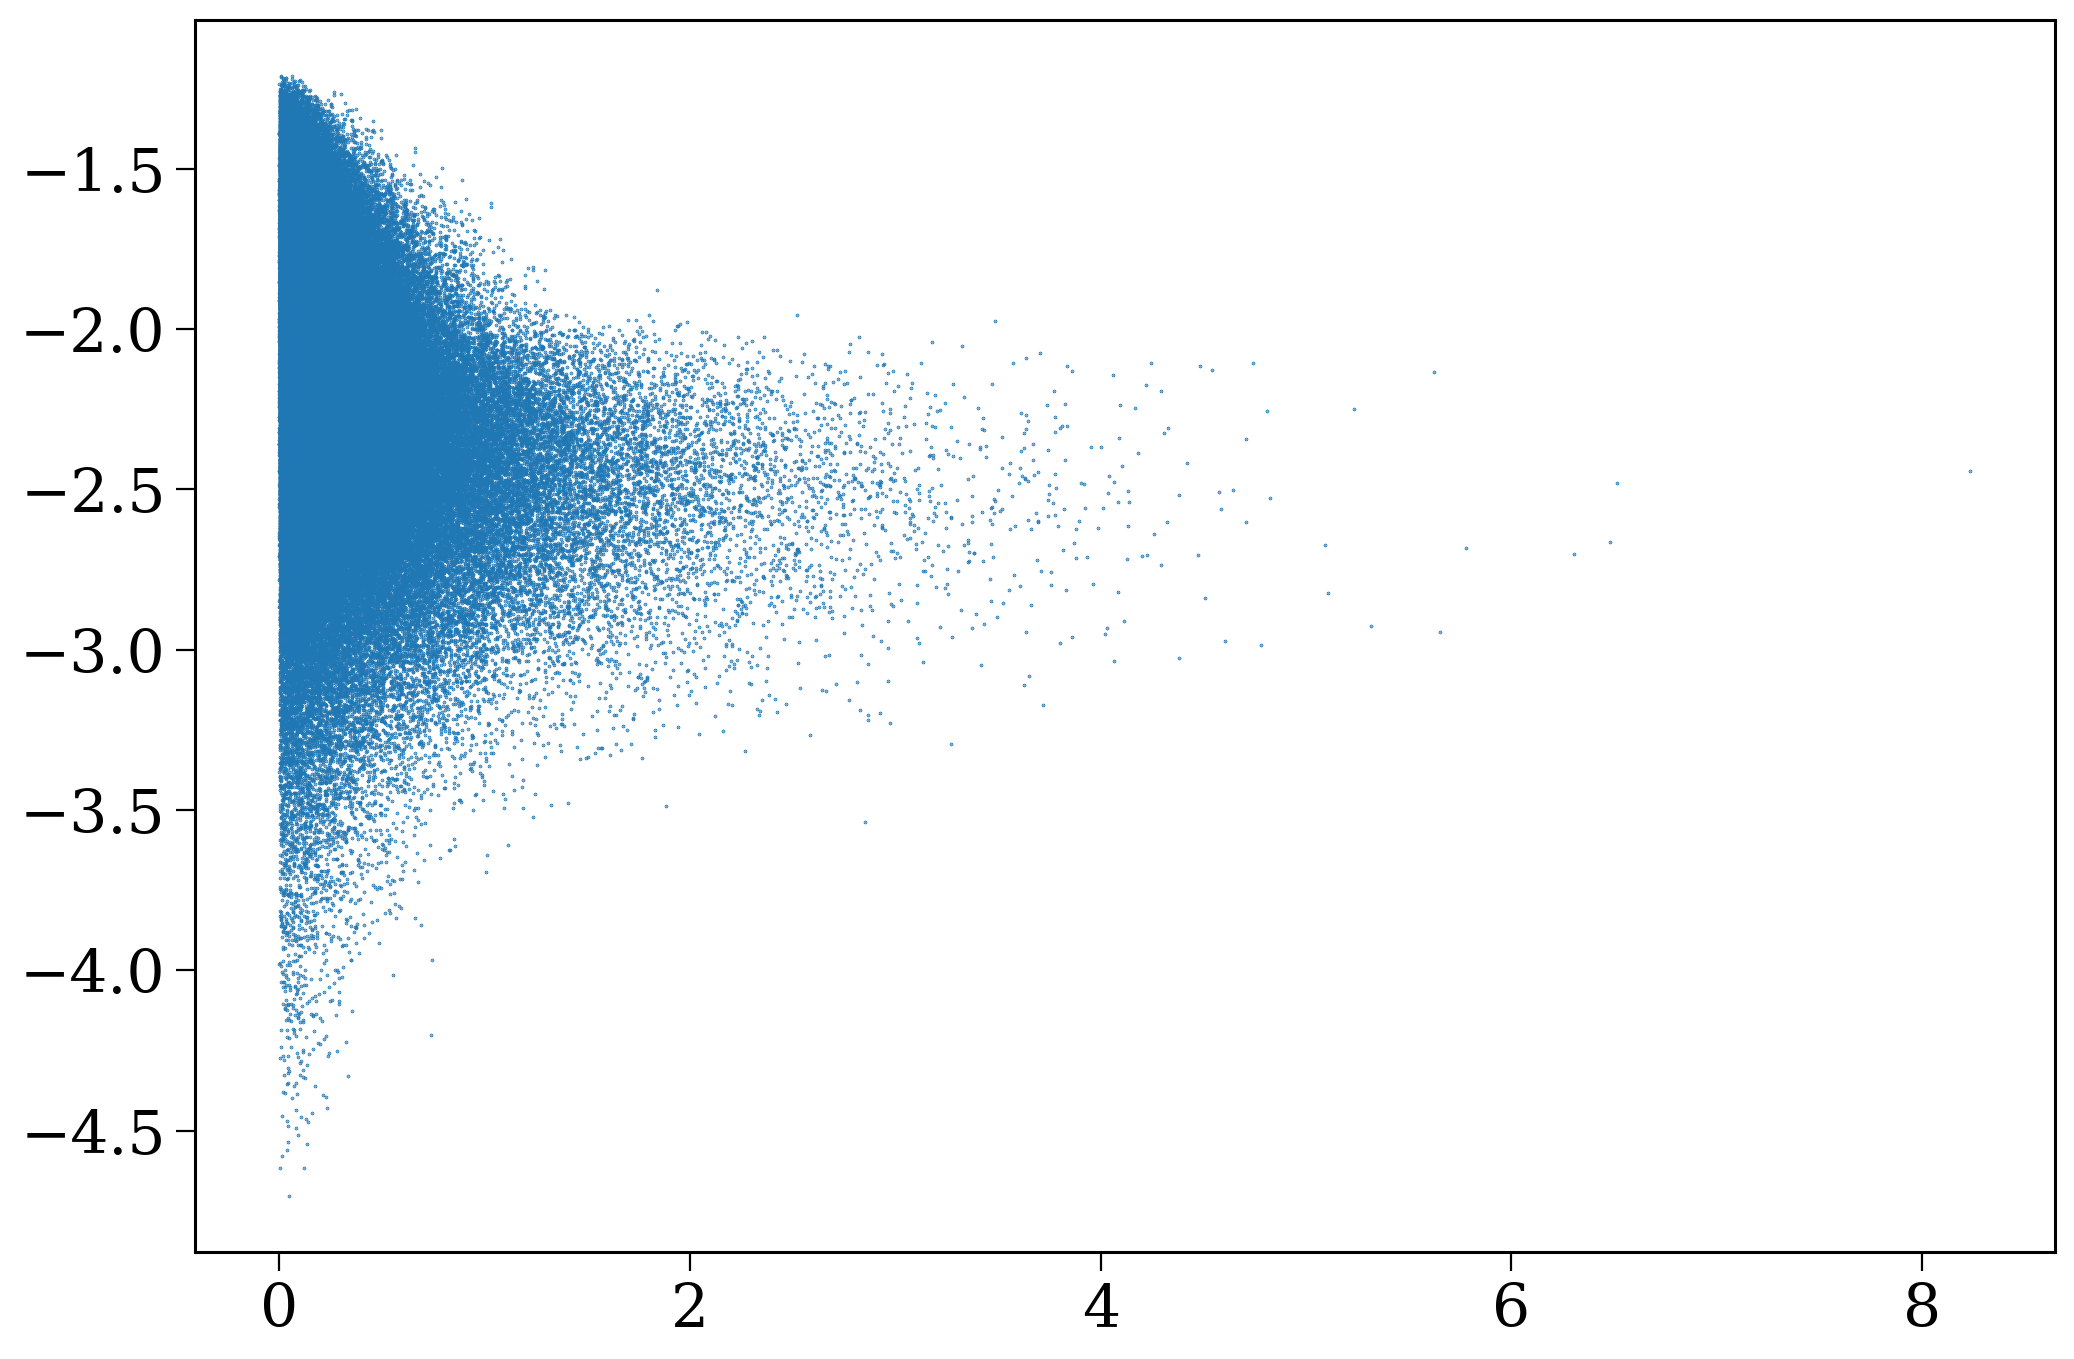

In [58]:
# scatter initial Z and z
plt.scatter(abs(pop.initial_galaxy.z), np.log10(abs(pop.initial_galaxy.Z)), s=0.1)
plt.show()

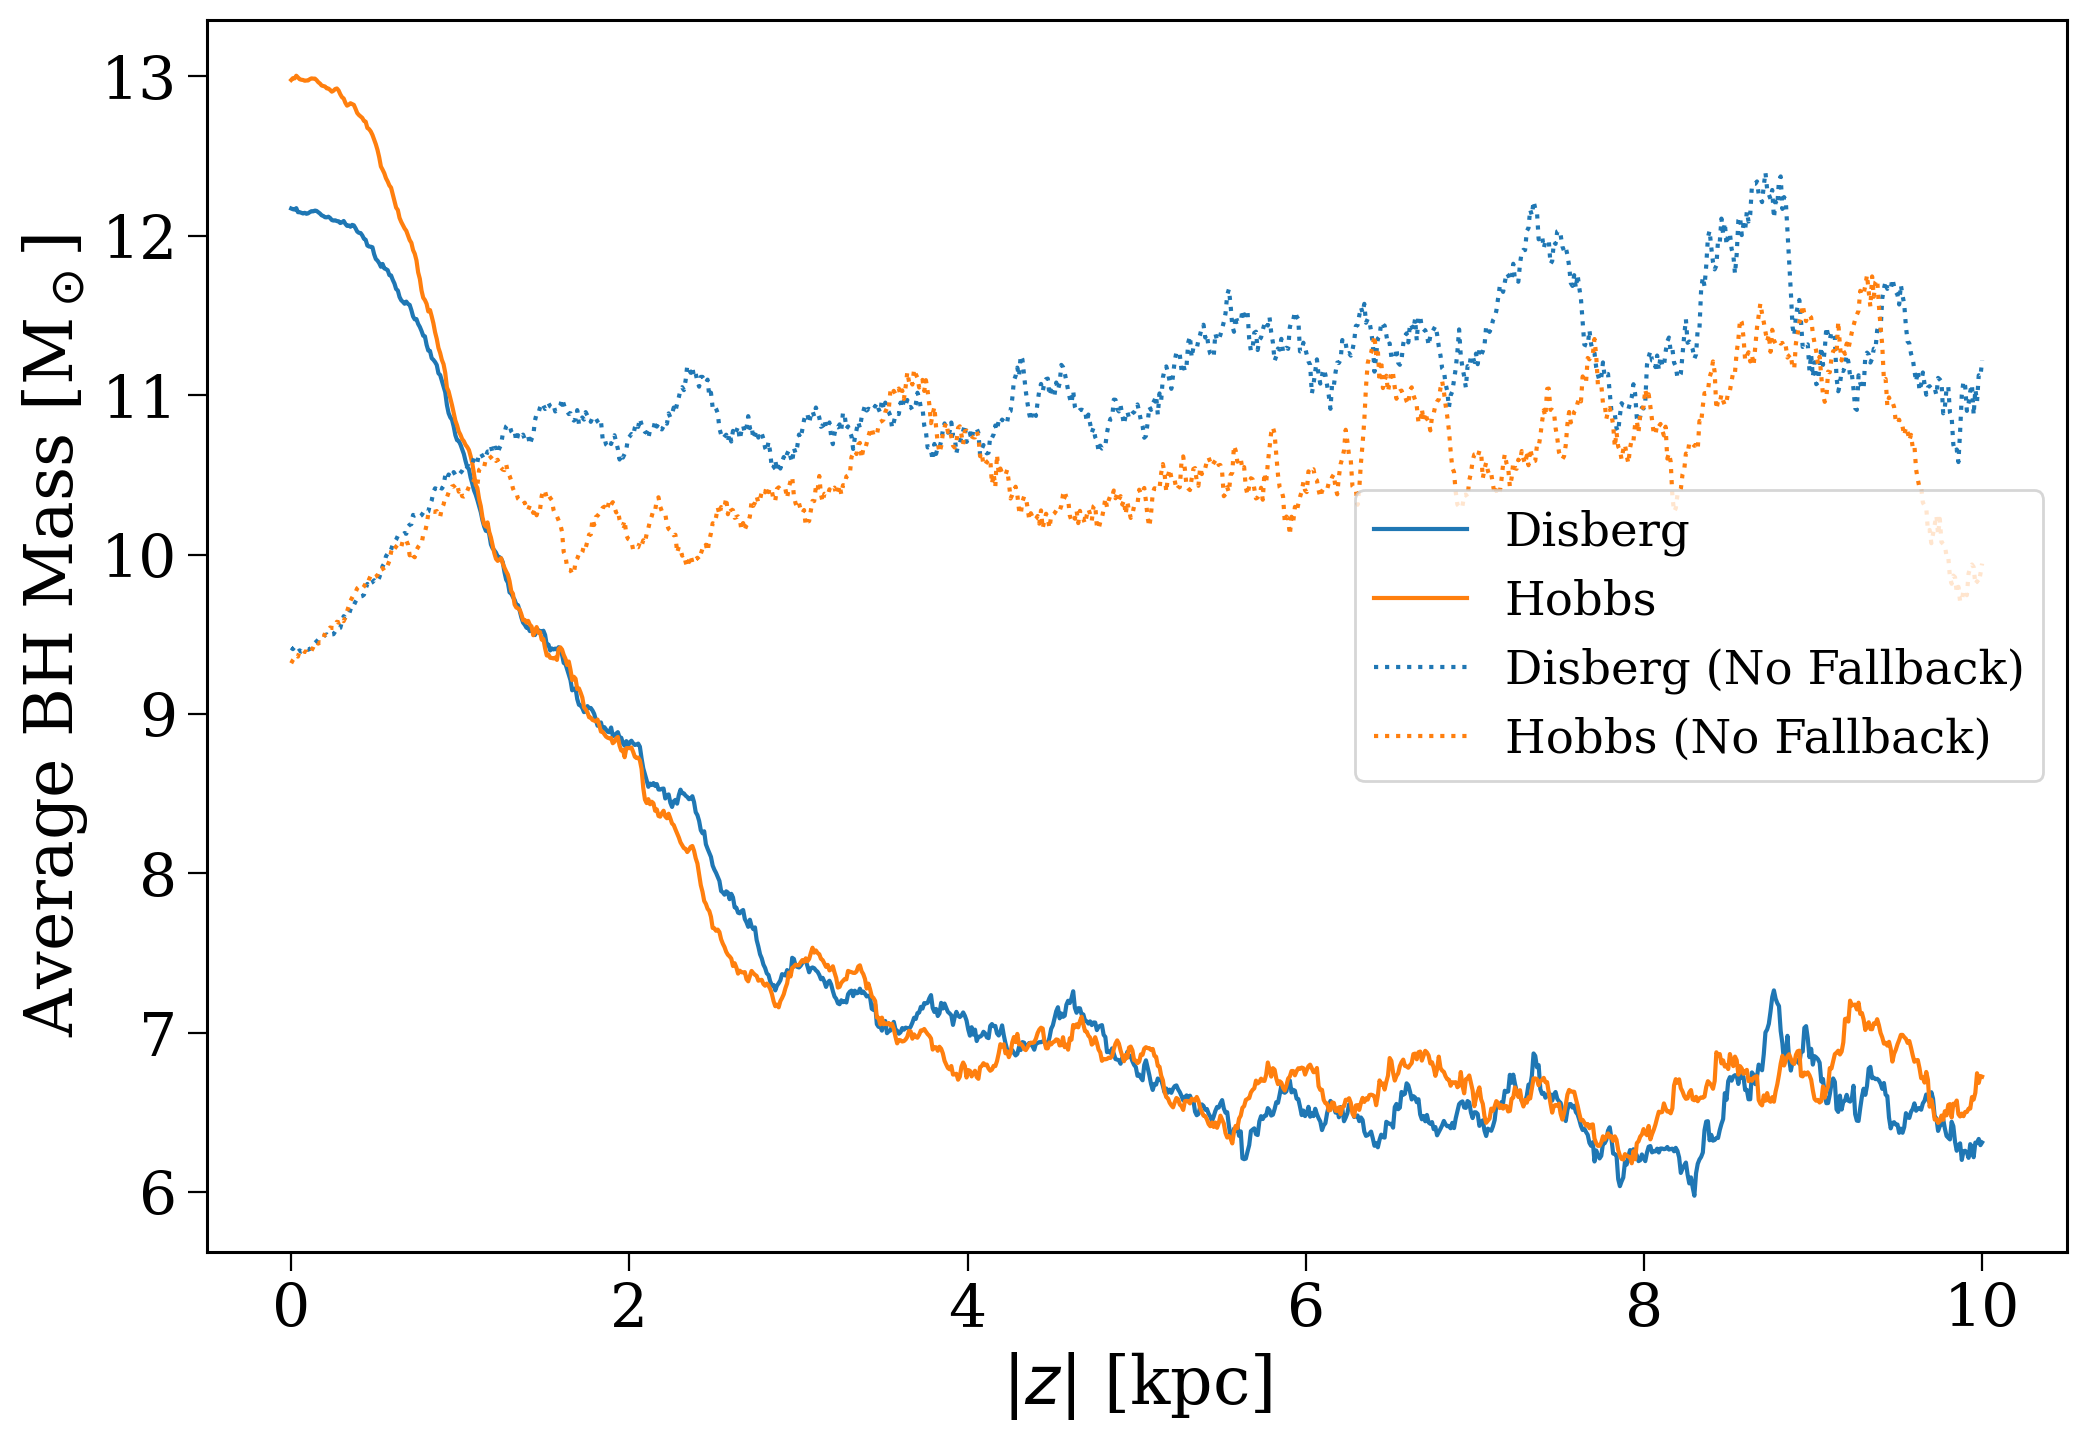

In [65]:
fig, ax = plt.subplots()

for pop in pops:
    ax.plot(z_range, 
            mean_bhs[pop.label],
            color=pop.colour,
            label=pop.label,
            linestyle=pop.linestyle,
    )

ax.set(
    xlabel=r'$|z|$ [kpc]',
    ylabel='Average BH Mass [M$_\odot$]',
)

ax.legend()

plt.show()